In [1]:
import json
from pathlib import Path
from typing import Self
from pydantic import BaseModel, Field
import matplotlib.pyplot as plt
import numpy as np
import model.occupancy as Occupancy
import model.lighting as Lighting
import model.hvac as HVAC
import model.equipment as Equipment
import translator.occupancy_translator as OccupancyTranslator
import translator.lighting_translator as LightingTranslator
# import stochastic.hvac_translator as HVACTranslator
# import stochastic.equipment_translator as EquipmentTranslator
# import stochastic.model_schedule_gen as ModelScheduleGenerator
import pandas as pd

## Helper

In [3]:
# Build a boolean mask for sleep times over the 7-day period
def build_sleep_mask(sleep_times):
    mask = np.zeros(7*24, dtype=bool)
    try:
        # 1) Global single [start, end] applied to every day
        if isinstance(sleep_times, (list, tuple)) and len(sleep_times) == 2 and all(isinstance(x, (int, float)) for x in sleep_times):
            s, e = int(sleep_times[0]), int(sleep_times[1])
            for d in range(7):
                start = d*24 + s
                end = d*24 + e
                if s <= e:
                    mask[start:end] = True
                else:  # wraps past midnight
                    mask[start:d*24+24] = True
                    mask[d*24:end] = True
            return mask

        # 2) Per-day list/tuple of 7 entries: [(s,e), (s,e), ...]
        if isinstance(sleep_times, (list, tuple)) and len(sleep_times) == 7:
            for d, entry in enumerate(sleep_times):
                if entry is None:
                    continue
                # entry can be (s,e) or dict with start_hour/end_hour
                if isinstance(entry, (list, tuple)) and len(entry) == 2:
                    s, e = int(entry[0]), int(entry[1])
                elif isinstance(entry, dict):
                    s = int(entry.get('start_hour', 0))
                    e = int(entry.get('end_hour', 0))
                else:
                    # unexpected format for this day; skip
                    continue
                start = d*24 + s
                end = d*24 + e
                if s <= e:
                    if start < end:
                        mask[start:end] = True
                else:
                    mask[start:d*24+24] = True
                    mask[d*24:end] = True
            return mask

        # 3) Dict formats: weekday_sleep_time / weekend_sleep_time or generic keys
        if isinstance(sleep_times, dict):
            for d in range(7):
                is_weekend = d >= 5
                key = 'weekend_sleep_time' if is_weekend else 'weekday_sleep_time'
                if key in sleep_times and isinstance(sleep_times[key], dict):
                    st = sleep_times[key]
                    s = int(st.get('start_hour', 0))
                    e = int(st.get('end_hour', 0))
                elif 'weekday' in sleep_times and 'weekend' in sleep_times and isinstance(sleep_times['weekday'], dict):
                    st = sleep_times['weekend'] if is_weekend else sleep_times['weekday']
                    s = int(st.get('start_hour', 0))
                    e = int(st.get('end_hour', 0))
                else:
                    s = int(sleep_times.get('start_hour', 0))
                    e = int(sleep_times.get('end_hour', 0))
                start = d*24 + s
                end = d*24 + e
                if s <= e:
                    mask[start:end] = True
                else:
                    mask[start:d*24+24] = True
                    mask[d*24:end] = True
            return mask
    except Exception:
        # If anything goes wrong, return the mask as-is (safe failure)
        pass
    return mask

In [4]:
day_label = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

## Total

In [2]:
json_path =  Path("../test/sample_data/broken.json")
model_gen = ModelScheduleGenerator.ModelScheduleGenerator(json_path)
annual_schedule = model_gen.generate_annual_schedule()

In [3]:
dataframe = pd.DataFrame(annual_schedule)
dataframe.to_csv("../test/sample_output/annual_schedule_2.csv")


## Occupancy

In [2]:
file_path = Path("../test/sample_data/case2.json")

with open(file_path, 'r') as f:
    raw_data = json.load(f)
    
occupancy_data = raw_data.get("occupancy")

occupants_2 = Occupancy.Occupancy.model_validate(occupancy_data)
occupancy_assumption = OccupancyTranslator.OccupancyAssumptions.default()
occupant_model = OccupancyTranslator.OccupancyTranslator(occupants_2, occupancy_assumption)
occupancy,sleep = occupant_model.get_annual_schedule()

In [12]:
week_schedule = occupancy[0]

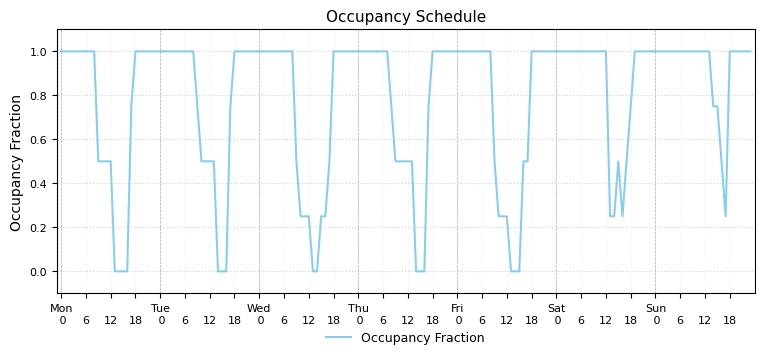

In [14]:

day_boundaries = np.arange(0, 7*24, 24)
hour_boundaries = np.arange(0, 7*24, 6)
plt.figure(figsize=(9, 4)) 
plt.ylim(0, 1.1)
plt.xlim(-1, 7*24)

plt.plot(week_schedule, linestyle='-', color='skyblue', label='Occupancy Fraction')

# 2. Add Vertical Grid Lines (for each day boundary)
# Use axvline to draw distinct lines at the start of each day
for boundary in day_boundaries:
    plt.axvline(x=boundary, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

for h in hour_boundaries:
    plt.axvline(x=h, color='lightgray', linestyle=':', linewidth=0.5, alpha=0.5)

# 3. Add Minor Grid (Optional: for hourly visualization)
plt.grid(axis='y', linestyle=':', alpha=0.6) 



# 4. Set X-axis Ticks and Labels: combine day name and hour on separate lines
hour_labels = []
for h in hour_boundaries:
    day_idx = int(h // 24)  
    hour_of_day = int(h % 24)
    day_name = day_label[day_idx] if day_idx < len(day_label) else f'Day {day_idx+1}'
    if hour_of_day == 0:
        hour_labels.append(f"{day_name}\n 0")
    else:
        hour_labels.append(f"\n{hour_of_day}")
plt.xticks(ticks=hour_boundaries, labels=hour_labels, fontsize=8)
plt.yticks(fontsize=8)

plt.title('Occupancy Schedule', fontsize=11)
plt.ylim(-0.1, 1.1)
plt.xlim(-1, 7*24)
#plt.xlabel('Day / Hour', fontsize =10)
plt.ylabel('Occupancy Fraction', fontsize=10)
# Place legend below the x-axis to match other plots
plt.subplots_adjust(bottom=0.22)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), ncol=3, frameon=False,fontsize = 9)
plt.show()

## Lighting

In [5]:
ligthing_data = raw_data.get("lighting")
lighting = Lighting.Lighting.model_validate(ligthing_data)
lighting_model = LightingTranslator.LightingTranslator(lighting)
lighting_schedule = lighting_model.translate_lighting_schedule_annual(occupancy, sleep)

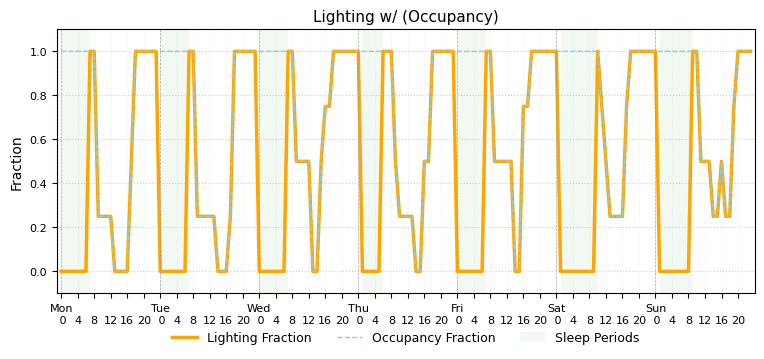

In [7]:
# Combined plot: Lighting (bold) + Occupancy (lighter) + Sleep shading
day_boundaries = np.arange(0, 7*24, 24)
hour_boundaries = np.arange(0, 7*24, 4)
plt.figure(figsize=(9, 4))
plt.ylim(-0.1, 1.1)
plt.xlim(-1, 7*24)

# Lighting: prominent orange line
plt.plot(lighting_schedule[0], linestyle='-', color='orange', linewidth=2.5, label='Lighting Fraction')

# Occupancy: lighter blue line for comparison
plt.plot(occupancy[0], linestyle='--', color='skyblue', linewidth=1.0, alpha=1.0, label='Occupancy Fraction', zorder=4)



# Shade sleep periods lightly across the timeline
# Use axvspan for contiguous spans to keep the plot fast and readable
i = 0
cnt = 0
while i < len(sleep[0]):
    if sleep[0][i]:
        start = i
        while i < len(sleep[0]) and sleep[0][i]:
            i += 1
        end = i
        if cnt == 0:
            plt.axvspan(start, end, color='green', alpha=0.05, linewidth=0, label='Sleep Periods')
            cnt += 1
        else:
            plt.axvspan(start, end, color='green', alpha=0.05, linewidth=0)
    else:
        i += 1

# Add day/hour grid lines
for boundary in day_boundaries:
    plt.axvline(x=boundary, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
for h in hour_boundaries:
    plt.axvline(x=h, color='lightgray', linestyle=':', linewidth=0.5, alpha=0.5)
plt.grid(axis='y', linestyle=':', alpha=0.6)

# 4. Set X-axis Ticks and Labels: combine day name and hour on separate lines
hour_labels = []
for h in hour_boundaries:
    day_idx = int(h // 24)  
    hour_of_day = int(h % 24)
    day_name = day_label[day_idx] if day_idx < len(day_label) else f'Day {day_idx+1}'
    if hour_of_day == 0:
        hour_labels.append(f"{day_name}\n 0")
    else:
        hour_labels.append(f"\n{hour_of_day}")
plt.xticks(ticks=hour_boundaries, labels=hour_labels, fontsize =8)

plt.yticks(fontsize=8)

plt.title('Lighting w/ (Occupancy)', fontsize=11)
#plt.xlabel('Day / Hour')
plt.ylabel('Fraction',fontsize =10)
plt.subplots_adjust(bottom=0.22)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False,fontsize = 9)
plt.show()


## HVAC

In [68]:
hvac_data = raw_data.get("hvac")
hvac = HVAC.HVAC.model_validate(hvac_data)
hvac_model = HVACTranslator.HVACTranslator(hvac)
heating_schedule = hvac_model.translate_heating_setpoint_schedule(week_schedule2, sleep_times)
cooling_schedule = hvac_model.translate_cooling_setpoint_schedule(week_schedule2, sleep_times)
heating_availability_schedule = hvac_model.translate_heating_availability_schedule(week_schedule2, sleep_times)
cooling_availability_schedule = hvac_model.translate_cooling_availability_schedule(week_schedule2, sleep_times)

In [69]:
np.min(heating_schedule), np.max(heating_schedule)
np.min(cooling_schedule), np.max(cooling_schedule)

(np.float64(24.0), np.float64(35.0))

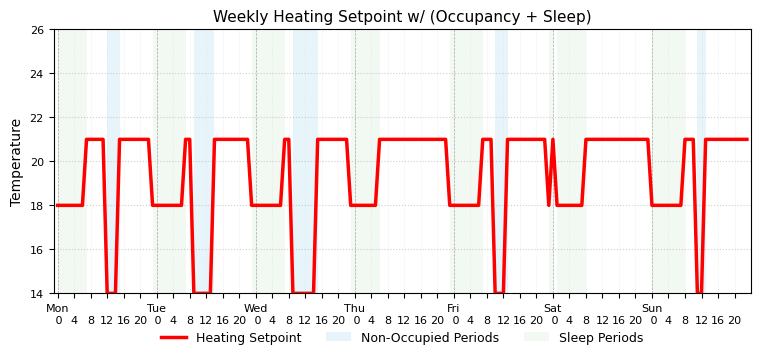

In [70]:
day_boundaries = np.arange(0, 7*24, 24)
hour_boundaries = np.arange(0, 7*24, 4)
plt.figure(figsize=(9, 4))
plt.ylim(14, 26)
plt.xlim(-1, 7*24)

# Heating: prominent orange line
plt.plot(heating_schedule, linestyle='-', color='red', linewidth=2.5, label='Heating Setpoint', zorder=4)



# Non-occupied mask based on occupancy fraction (treat <=1% as empty)
occupancy_arr = np.asarray(week_schedule2)
non_occupied_mask = occupancy_arr <= 0.01

# Shade non-occupied periods first (background)
j = 0
cnt = 0
while j < len(non_occupied_mask):
    if non_occupied_mask[j]:
        s = j
        while j < len(non_occupied_mask) and non_occupied_mask[j]:
            j += 1
        e = j
        if cnt == 0:
            plt.axvspan(s, e, color='skyblue', alpha=0.2, linewidth=0, zorder=0, label='Non-Occupied Periods')
            cnt += 1
        else:
            plt.axvspan(s, e, color='skyblue', alpha=0.2, linewidth=0, zorder=0)
    else:
        j += 1

# Shade sleep periods lightly across the timeline (on top of non-occupied shading)
i = 0
cnt = 0
while i < len(sleep_mask):
    if sleep_mask[i]:
        start = i
        while i < len(sleep_mask) and sleep_mask[i]:
            i += 1
        end = i
        if cnt == 0:
            plt.axvspan(start, end, color='green', alpha=0.05, linewidth=0, zorder=1, label='Sleep Periods')
            cnt += 1
        else:
            plt.axvspan(start, end, color='green', alpha=0.05, linewidth=0, zorder=1)
    else:
        i += 1

# Add day/hour grid lines
for boundary in day_boundaries:
    plt.axvline(x=boundary, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
for h in hour_boundaries:
    plt.axvline(x=h, color='lightgray', linestyle=':', linewidth=0.5, alpha=0.5)
plt.grid(axis='y', linestyle=':', alpha=0.6)

# 4. Set X-axis Ticks and Labels: combine day name and hour on separate lines
hour_labels = []
for h in hour_boundaries:
    day_idx = int(h // 24)  
    hour_of_day = int(h % 24)
    day_name = day_label[day_idx] if day_idx < len(day_label) else f'Day {day_idx+1}'
    if hour_of_day == 0:
        hour_labels.append(f"{day_name}\n 0")
    else:
        hour_labels.append(f"\n{hour_of_day}")
plt.xticks(ticks=hour_boundaries, labels=hour_labels, fontsize=8)
plt.yticks(fontsize=8)

plt.title('Weekly Heating Setpoint w/ (Occupancy + Sleep)', fontsize=11)
#plt.xlabel('Day / Hour', fontsize=10)
plt.ylabel('Temperature', fontsize=10)
plt.subplots_adjust(bottom=0.22)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False,fontsize = 9)
plt.show()


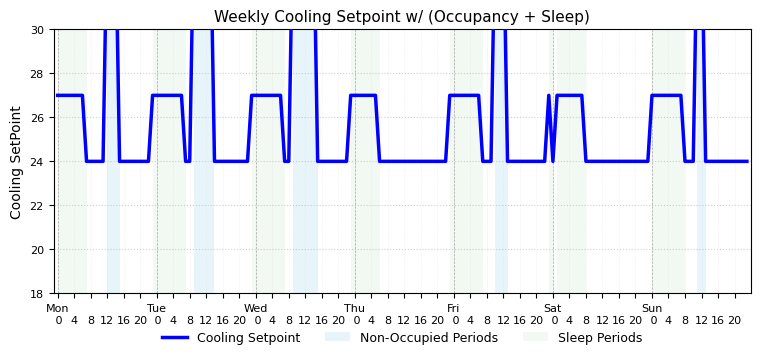

In [71]:
day_boundaries = np.arange(0, 7*24, 24)
hour_boundaries = np.arange(0, 7*24, 4)
plt.figure(figsize=(9, 4))
plt.xlim(-1, 7*24)
plt.ylim(18, 30)

# Heating: prominent orange line
plt.plot(cooling_schedule, linestyle='-', color='blue', linewidth=2.5, label='Cooling Setpoint', zorder=4)



sleep_mask = build_sleep_mask(sleep_times)

# Non-occupied mask based on occupancy fraction (treat <=1% as empty)
occupancy_arr = np.asarray(week_schedule2)
non_occupied_mask = occupancy_arr <= 0.01

# Shade non-occupied periods first (background)
j = 0
cnt = 0
while j < len(non_occupied_mask):
    if non_occupied_mask[j]:
        s = j
        while j < len(non_occupied_mask) and non_occupied_mask[j]:
            j += 1
        e = j
        if cnt == 0:
            plt.axvspan(s, e, color='skyblue', alpha=0.2, linewidth=0, zorder=0, label='Non-Occupied Periods')
            cnt += 1
        else:
            plt.axvspan(s, e, color='skyblue', alpha=0.2, linewidth=0, zorder=0)
    else:
        j += 1

# Shade sleep periods lightly across the timeline (on top of non-occupied shading)
i = 0
cnt = 0
while i < len(sleep_mask):
    if sleep_mask[i]:
        start = i
        while i < len(sleep_mask) and sleep_mask[i]:
            i += 1
        end = i
        if cnt == 0:
            plt.axvspan(start, end, color='green', alpha=0.05, linewidth=0, zorder=1, label='Sleep Periods')
            cnt += 1
        else:
            plt.axvspan(start, end, color='green', alpha=0.05, linewidth=0, zorder=1)
    else:
        i += 1

# Add day/hour grid lines
for boundary in day_boundaries:
    plt.axvline(x=boundary, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
for h in hour_boundaries:
    plt.axvline(x=h, color='lightgray', linestyle=':', linewidth=0.5, alpha=0.5)
plt.grid(axis='y', linestyle=':', alpha=0.6)

# 4. Set X-axis Ticks and Labels: combine day name and hour on separate lines
hour_labels = []
for h in hour_boundaries:
    day_idx = int(h // 24)  
    hour_of_day = int(h % 24)
    day_name = day_label[day_idx] if day_idx < len(day_label) else f'Day {day_idx+1}'
    if hour_of_day == 0:
        hour_labels.append(f"{day_name}\n 0")
    else:
        hour_labels.append(f"\n{hour_of_day}")
plt.xticks(ticks=hour_boundaries, labels=hour_labels,fontsize=8)
plt.yticks(fontsize=8)

plt.title('Weekly Cooling Setpoint w/ (Occupancy + Sleep)', fontsize=11)
plt.ylabel('Cooling SetPoint',fontsize =10)
plt.subplots_adjust(bottom=0.22)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False,fontsize = 9)
plt.show()

## Equipment

In [72]:
equipment_data = raw_data.get("equipment")
equipment = Equipment.Equipment.model_validate(equipment_data)
equipment_model = EquipmentTranslator.EquipmentTranslator(equipment, occupant_model)
equip_total = equipment_model.get_equipment_usage_schedule()
laundry_schedule = equipment_model.get_laundry_usage_schedule()
fridge_schedule = equipment_model.get_fridge_usage_schedule()
dishwasher_schedule = equipment_model.get_dishwasher_usage_schedule()
cooking_schedule = equipment_model.get_kitchen_usage_schedule()

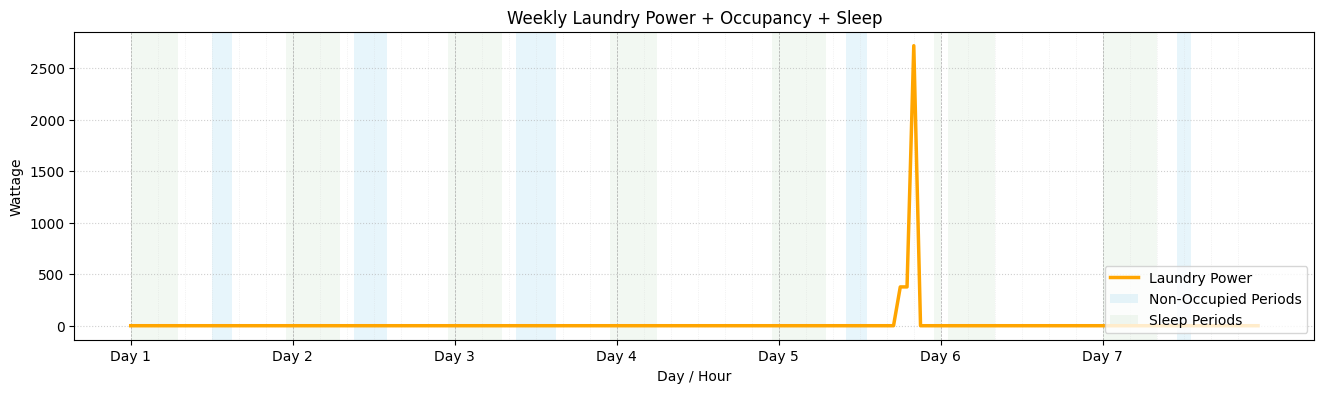

In [73]:
day_boundaries = np.arange(0, 7*24, 24)
hour_boundaries = np.arange(0, 7*24, 4)
plt.figure(figsize=(16, 4))

# Heating: prominent orange line
plt.plot(laundry_schedule, linestyle='-', color='orange', linewidth=2.5, label='Laundry Power', zorder=4)

# Non-occupied mask based on occupancy fraction (treat <=1% as empty)
occupancy_arr = np.asarray(week_schedule2)
non_occupied_mask = occupancy_arr <= 0.01

# Shade non-occupied periods first (background)
j = 0
cnt = 0
while j < len(non_occupied_mask):
    if non_occupied_mask[j]:
        s = j
        while j < len(non_occupied_mask) and non_occupied_mask[j]:
            j += 1
        e = j
        if cnt == 0:
            plt.axvspan(s, e, color='skyblue', alpha=0.2, linewidth=0, zorder=0, label='Non-Occupied Periods')
            cnt += 1
        else:
            plt.axvspan(s, e, color='skyblue', alpha=0.2, linewidth=0, zorder=0)
    else:
        j += 1

# Shade sleep periods lightly across the timeline (on top of non-occupied shading)
i = 0
cnt = 0
while i < len(sleep_mask):
    if sleep_mask[i]:
        start = i
        while i < len(sleep_mask) and sleep_mask[i]:
            i += 1
        end = i
        if cnt == 0:
            plt.axvspan(start, end, color='green', alpha=0.05, linewidth=0, zorder=1, label='Sleep Periods')
            cnt += 1
        else:
            plt.axvspan(start, end, color='green', alpha=0.05, linewidth=0, zorder=1)
    else:
        i += 1

# Add day/hour grid lines
for boundary in day_boundaries:
    plt.axvline(x=boundary, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
for h in hour_boundaries:
    plt.axvline(x=h, color='lightgray', linestyle=':', linewidth=0.5, alpha=0.5)
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.xticks(
    ticks=day_boundaries,
    labels=[f'Day {i+1}' for i in range(len(day_boundaries) - 1)] + ['Day 7']
)

plt.title('Weekly Laundry Power + Occupancy + Sleep')
plt.xlabel('Day / Hour')
plt.ylabel('Wattage')
plt.legend(loc='lower right')
plt.show()

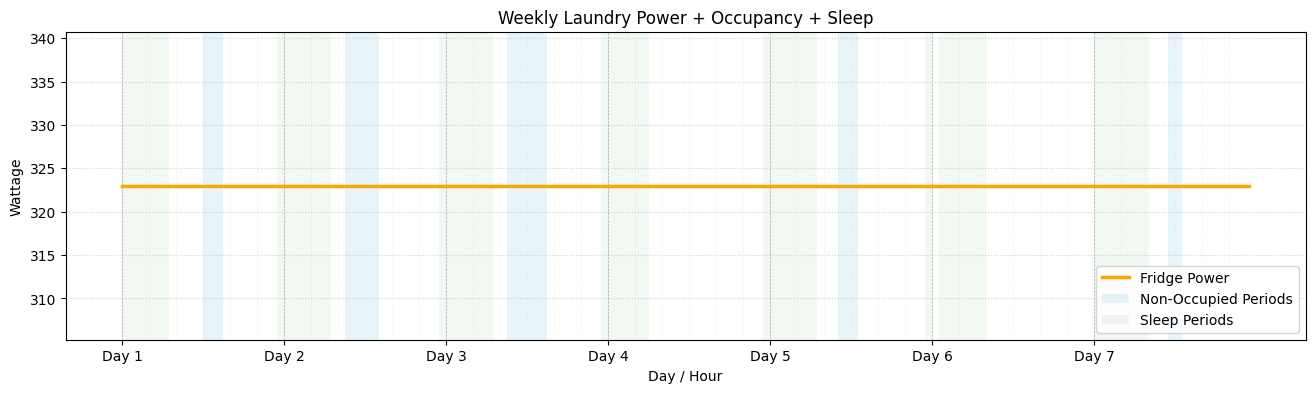

In [74]:
day_boundaries = np.arange(0, 7*24, 24)
hour_boundaries = np.arange(0, 7*24, 4)
plt.figure(figsize=(16, 4))

# Heating: prominent orange line
plt.plot(fridge_schedule, linestyle='-', color='orange', linewidth=2.5, label='Fridge Power', zorder=4)

# Non-occupied mask based on occupancy fraction (treat <=1% as empty)
occupancy_arr = np.asarray(week_schedule2)
non_occupied_mask = occupancy_arr <= 0.01

# Shade non-occupied periods first (background)
j = 0
cnt = 0
while j < len(non_occupied_mask):
    if non_occupied_mask[j]:
        s = j
        while j < len(non_occupied_mask) and non_occupied_mask[j]:
            j += 1
        e = j
        if cnt == 0:
            plt.axvspan(s, e, color='skyblue', alpha=0.2, linewidth=0, zorder=0, label='Non-Occupied Periods')
            cnt += 1
        else:
            plt.axvspan(s, e, color='skyblue', alpha=0.2, linewidth=0, zorder=0)
    else:
        j += 1

# Shade sleep periods lightly across the timeline (on top of non-occupied shading)
i = 0
cnt = 0
while i < len(sleep_mask):
    if sleep_mask[i]:
        start = i
        while i < len(sleep_mask) and sleep_mask[i]:
            i += 1
        end = i
        if cnt == 0:
            plt.axvspan(start, end, color='green', alpha=0.05, linewidth=0, zorder=1, label='Sleep Periods')
            cnt += 1
        else:
            plt.axvspan(start, end, color='green', alpha=0.05, linewidth=0, zorder=1)
    else:
        i += 1

# Add day/hour grid lines
for boundary in day_boundaries:
    plt.axvline(x=boundary, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
for h in hour_boundaries:
    plt.axvline(x=h, color='lightgray', linestyle=':', linewidth=0.5, alpha=0.5)
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.xticks(
    ticks=day_boundaries,
    labels=[f'Day {i+1}' for i in range(len(day_boundaries) - 1)] + ['Day 7']
)

plt.title('Weekly Laundry Power + Occupancy + Sleep')
plt.xlabel('Day / Hour')
plt.ylabel('Wattage')
plt.legend(loc='lower right')
plt.show()

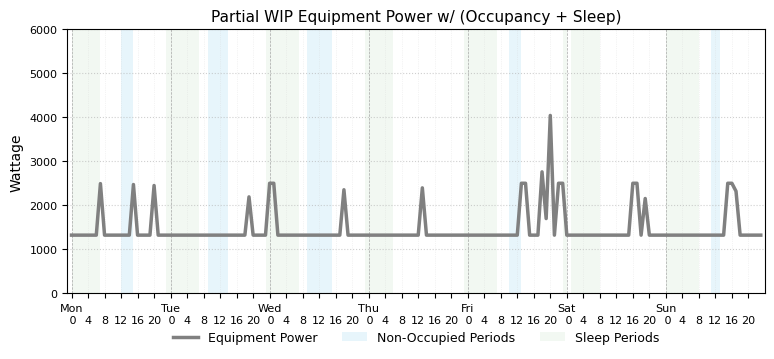

In [75]:
day_boundaries = np.arange(0, 7*24, 24)
hour_boundaries = np.arange(0, 7*24, 4)
plt.figure(figsize=(9, 4))
plt.xlim(-1,7*24)
plt.ylim(0,6000)

# Heating: prominent orange line
plt.plot(equip_total, linestyle='-', color='gray', linewidth=2.5, label='Equipment Power', zorder=4)

# Non-occupied mask based on occupancy fraction (treat <=1% as empty)
occupancy_arr = np.asarray(week_schedule2)
non_occupied_mask = occupancy_arr <= 0.01

# Add day/hour grid lines
for boundary in day_boundaries:
    plt.axvline(x=boundary, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
for h in hour_boundaries:
    plt.axvline(x=h, color='lightgray', linestyle=':', linewidth=0.5, alpha=0.5)
plt.grid(axis='y', linestyle=':', alpha=0.6)

# Shade non-occupied periods first (background)
j = 0
cnt = 0
while j < len(non_occupied_mask):
    if non_occupied_mask[j]:
        s = j
        while j < len(non_occupied_mask) and non_occupied_mask[j]:
            j += 1
        e = j
        if cnt == 0:
            plt.axvspan(s, e, color='skyblue', alpha=0.2, linewidth=0, zorder=0, label='Non-Occupied Periods')
            cnt += 1
        else:
            plt.axvspan(s, e, color='skyblue', alpha=0.2, linewidth=0, zorder=0)
    else:
        j += 1

# Shade sleep periods lightly across the timeline (on top of non-occupied shading)
i = 0
cnt = 0
while i < len(sleep_mask):
    if sleep_mask[i]:
        start = i
        while i < len(sleep_mask) and sleep_mask[i]:
            i += 1
        end = i
        if cnt == 0:
            plt.axvspan(start, end, color='green', alpha=0.05, linewidth=0, zorder=1, label='Sleep Periods')
            cnt += 1
        else:
            plt.axvspan(start, end, color='green', alpha=0.05, linewidth=0, zorder=1)
    else:
        i += 1

# Add day/hour grid lines
hour_labels = []
for h in hour_boundaries:
    day_idx = int(h // 24)  
    hour_of_day = int(h % 24)
    day_name = day_label[day_idx] if day_idx < len(day_label) else f'Day {day_idx+1}'
    if hour_of_day == 0:
        hour_labels.append(f"{day_name}\n 0")
    else:
        hour_labels.append(f"\n{hour_of_day}")
plt.xticks(ticks=hour_boundaries, labels=hour_labels, fontsize=8)
plt.yticks(fontsize=8)

plt.title('Partial WIP Equipment Power w/ (Occupancy + Sleep)',fontsize = 11)
#plt.xlabel('Day / Hour')
plt.ylabel('Wattage',fontsize = 10)
plt.subplots_adjust(bottom=0.22)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False,fontsize = 9)
plt.show()